In [2]:
using Pkg
Pkg.activate("..")
using LinearAlgebra, Plots, ITensors, ITensorMPS, DelimitedFiles

  Activating project at `c:\Users\mariu\GithubCloneTN\TN_Notebooks`


# Week 2: Matrix Product States

**Note:** For this notebook, you will need to use the `ITensorMPS` package. If not yet install, open a notebook cell, write, and execute the following:
```julia
import Pkg; Pkg.add("ITensorMPS")
```

Today we're going to study how matrix product states (MPS) work as representation of many-body quantum states.
Especially, we will see how MPS *can* be more compact than an explicit representation of the quantum state as an element of the Hilbert space, and how they store information about the quantum state.

To help you through out this notebook, here is the link to the `ITensors` and `ITensorMPS` documentations: [https://docs.itensor.org/Overview/](https://docs.itensor.org/Overview/).

## Exercise 1: The curse of dimensionality

In this exercise, we want to get a feeling for the "*curse of dimensionality*", and how tensor networks (TNs) offer a work around.

We will work with the GHZ state that was introduced in the lecture
$$|\text{GHZ}\rangle = \frac{1}{\sqrt{2}}\left(|0\rangle^{\otimes N} + |0\rangle^{\otimes N}\right) \ ,$$
where $|0\rangle = (1\ 0)^T$ and $|1\rangle = (0\ 1)^T$.

### **1) Creating the GHZ state**

**1.1)** Define the single-particle states `ket0` and `ket1`

**1.2)** Write a recursive function `tensorpower` that takes as an input a single-particle state $|\phi\rangle$ and an integer $N$ and returns a $N$-body state $|\phi\rangle^{\otimes N}$

**1.3)** Write a function `GHZstate` that takes as an input an integer $N$ and returns the GHZ state

**1.4)** Call `GHZstate` for $N = 3, 5, 10, 100,$ etc. What do you notice?

In [3]:
i = Index(2)

ket0 = ITensor(ComplexF64, ComplexF64[1, 0], i)
ket1 = ITensor(ComplexF64, ComplexF64[0, 1], i)

function tensorpower(state::ITensor, N::Integer)
    inds(state)
    if N==0
        return []
    else
    stateMatrix = Vector(state, inds(state))
    #print(stateMatrix)
    M = stateMatrix
    for l in range(2, N)
        M = kron(M, stateMatrix)
    end
    indizes = []
    for l in range(1, N)
        index = Index(2)
        push!(indizes, index)
        end
    #print(indizes)
    res = ITensor(ComplexF64, M, indizes)
    #print(inds(res))
    return res
    end
end
tensorpower(ket0, 3)

function GHZstate(N::Integer)
    tensor0 = tensorpower(ket0, N)
    tensor1 = ITensor(ComplexF64, array(tensorpower(ket1, N)), inds(tensor0))
    return 1/sqrt(2)*(tensor0 + tensor1)
end
println("N=3:")
println(GHZstate(3))
println("N=5:")
println(GHZstate(5))
println("N=10:")
println(GHZstate(10))
println("N=50:")
println(GHZstate(50))





N=3:
ITensor ord=3
Dim 1: (dim=2|id=938)
Dim 2: (dim=2|id=285)
Dim 3: (dim=2|id=758)
NDTensors.Dense{ComplexF64, Vector{ComplexF64}}
 2×2×2
[:, :, 1] =
 0.7071067811865475 + 0.0im  0.0 + 0.0im
                0.0 + 0.0im  0.0 + 0.0im

[:, :, 2] =
 0.0 + 0.0im                 0.0 + 0.0im
 0.0 + 0.0im  0.7071067811865475 + 0.0im

N=5:
ITensor ord=5
Dim 1: (dim=2|id=307)
Dim 2: (dim=2|id=415)
Dim 3: (dim=2|id=439)
Dim 4: (dim=2|id=492)
Dim 5: (dim=2|id=109)
NDTensors.Dense{ComplexF64, Vector{ComplexF64}}
 2×2×2×2×2
[:, :, 1, 1, 1] =
 0.7071067811865475 + 0.0im  0.0 + 0.0im
                0.0 + 0.0im  0.0 + 0.0im

[:, :, 2, 1, 1] =
 0.0 + 0.0im  0.0 + 0.0im
 0.0 + 0.0im  0.0 + 0.0im

[:, :, 1, 2, 1] =
 0.0 + 0.0im  0.0 + 0.0im
 0.0 + 0.0im  0.0 + 0.0im

[:, :, 2, 2, 1] =
 0.0 + 0.0im  0.0 + 0.0im
 0.0 + 0.0im  0.0 + 0.0im

[:, :, 1, 1, 2] =
 0.0 + 0.0im  0.0 + 0.0im
 0.0 + 0.0im  0.0 + 0.0im

[:, :, 2, 1, 2] =
 0.0 + 0.0im  0.0 + 0.0im
 0.0 + 0.0im  0.0 + 0.0im

[:, :, 1, 2, 2] =
 0.0 + 0

OutOfMemoryError: OutOfMemoryError()

### **2) MPS representation of the GHZ state**

In `ITensorMPS`, MPS can be constructed from sites indices and a state list.

**2.1)** Construct two MPSs with $N$ site indices with the "Qubit" site type, one with a state list containing only the $|0\rangle$ state and the other with a state list containing only the $|1\rangle$ state. 

**2.2)** Sum the two MPS; Repeat the operation for $N = 3, 5, 10, 100,$ etc. What do you notice?

**2.3)** In the lecture, we constructed an MPS representation of the GHZ state but this representation is not unique. Inspect the tensors in the MPS you constructed to see how it is represented.

### **3) MPS representation of the product state**

We will now focus on the product state $|0\rangle^{\otimes N}$ only. 

**3.1)** In `ItensorMPS`, a MPS can also be constructed from a list of $d^N$ elements and sites indices. Using the function `tensorpower` that you wrote in **1)**, construct a MPS $M_1$ for $|0\rangle^{\otimes 10}$.

**3.2)** Using the MPS constructor from **2)** (that takes as an input sites indices and state list), construct a MPS $M_2$ for the same state $|0\rangle^{\otimes 10}$.

**3.3)** Are the two MPSs equal?

**3.4)** The function `linkdim` that takes as an input a MPS $A$ and an integer $k$ labelling a bond returns the bond dimension $D^A_k$. On the same figure, plot the bond dimensions of $M_1$ and $M_2$. Interpret the result.

## Exercise 2: Sum of MPSs

In this exercise, we will experiment with the implementation of the sum of two MPSs in `ITensorMPS`.

**1)** The function [`rand_mps`](https://docs.itensor.org/ITensorMPS/stable/MPSandMPO.html#ITensorMPS.random_mps-Tuple{Vector{%3C:Index}}) construct a random MPS with a bond dimension given by the argument `linkdims`. Construct two random 10-site MPSs with the "Qubit" site type called `\psi1` and `\psi2` with a bond dimension of 2, and add them to obtain the MPS `\psi`. What is the bond dimension of `\psi`?

**2)** Add `\psi` with itself to define the MPS `twoPsi`. What is the bond diemsion of `twoPsi`?

By default `ITensorMPS` truncate singular values with a truncation cutoff of 1e-15. Keyword arguments `cutoff` or `maxdim` can be given to the function `+` to specify the truncations.
If you don't want the simgular values to be truncated `alg="directsum"` has to be given to the function `+`.

**3)** Add `\psi` with itself as a direct sum to define the MPS `twoPsiDirect`. What is the bond diemsion of `twoPsiDirect`?

**4)** Pick a cutoff threshold of your choice. Add `\psi1` and `\psi2` with this cutoff to obtain the MPS `\phi`. Compute the inner product of `\phi` with itself and compare it with the expanded form of the inner product of `psi1` + `psi2`. Repeat for several thresholds.

## Exercise 3: Intuition about restricted rank approximation

In this exercise, we will work with rank-2 tensors (aka matrices) of correlated data to build some intuition about the SVD as a tool to compress information.

The mandrill is a very colourful monkey from west central Africa. We are going to load a mandrill as a matrix.

In [7]:
mandrillmatrix = readdlm("mandrill.dat")

256×512 Matrix{Float64}:
 0.631373  0.639216  0.635294  0.615686  …  0.34902   0.317647  0.341176
 0.552941  0.584314  0.662745  0.686275     0.364706  0.384314  0.376471
 0.513725  0.568627  0.537255  0.509804     0.32549   0.356863  0.380392
 0.615686  0.666667  0.623529  0.541176     0.403922  0.360784  0.360784
 0.592157  0.623529  0.627451  0.584314     0.372549  0.309804  0.368627
 0.658824  0.654902  0.52549   0.47451   …  0.32549   0.364706  0.372549
 0.4       0.419608  0.45098   0.47451      0.368627  0.333333  0.388235
 0.368627  0.34902   0.364706  0.368627     0.270588  0.317647  0.423529
 0.352941  0.345098  0.329412  0.388235     0.27451   0.294118  0.294118
 0.27451   0.27451   0.309804  0.301961     0.360784  0.266667  0.333333
 ⋮                                       ⋱            ⋮         
 0.223529  0.188235  0.215686  0.454902     0.52549   0.611765  0.47451
 0.129412  0.2       0.435294  0.6          0.631373  0.470588  0.541176
 0.168627  0.2       0.521569  0.50

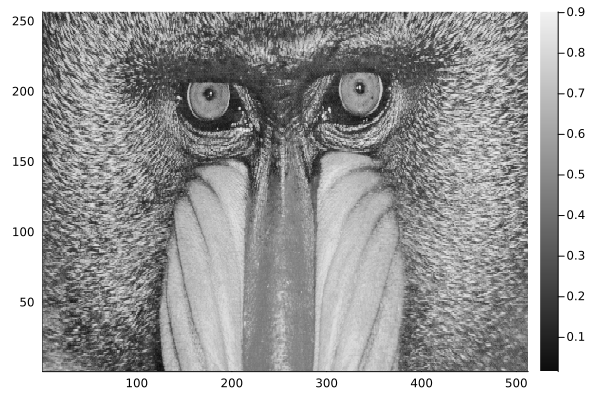

In [8]:
heatmap(mandrillmatrix, c=:grays)


**1)** Plot `mandrillmatrix` as a heatmap.

*Hint: Use a gray colour scheme for the heatmap with the keyword argument `c=:grays`.*

**2)** Find and plot the singular value spectrum of the matrix `mandrillmatrix` with a log-scale for the $y$-axis. Can you guess how many of them can be thrown away before the error (Frobenious distance) is larger than $1\%$?

**3)** By keeping only the $\chi$ largest singular values (and trimming the corresponding rows and columns of $U$ and $V^\dagger$) one can define a compressed version `mandrilltilde` of the same matrix.
Compute the truncation error for $\chi = 1, 2, \ldots$.

*Hint: a vector `v` can be turned into a diagonal matrix with `Diagonal(v)`.*

**4)** To get a feeling of the impact of the truncation error, plot the (truncated) amplitudes `mandrilltilde` for $\chi=1, 2, \ldots$ as a heatmap.

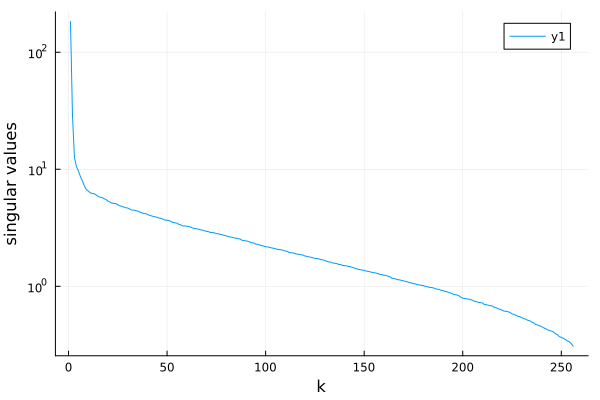

In [12]:
U, s, V = svd(mandrillmatrix)
plot(s, yscale=:log10, ylabel="singular values", xlabel="k")


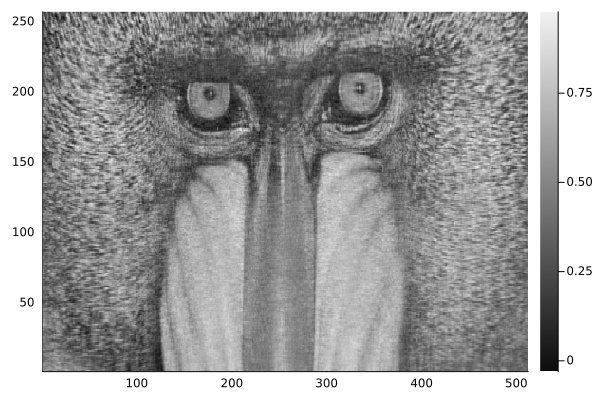

In [13]:
heatmap(U[:, 1:50]*Diagonal(s[1:50])*V'[1:50,:], c=:grays)

**5)** Repeat questions 1) to 4) for the matrix in `msc.dat` which contains information about the only person to win a Nobel Prize in two different scientific fields.

## Exercise 4: Bond dimension, Singular Value Spectrum, and von Neumann entropy

In this exercise, we will investigate the relation (of the lack thereof) between the bond dimension, the singular values and the von Neumann entropy of a quantum state.

We recall that the von Neumann entropy of a reduced state $\rho_{[1:\ell]}$ defined by the bipartition (1, $\ldots$, $\ell$ | $\ell+1, \ldots, N$) is given by

$$ S_1(\rho_{[1:\ell]}) = -\sum_{n=1}^{D_\ell} s_n^2 \ln(s_n^2)\ ,$$

where $D_\ell$ is the bond dimension of bond $\ell$ and $s_n$ are the singular values (Schmidt coefficients) at that bond.

### 1) GHZ state

**1.1)** The function `orthogonalize` takes as an input a MPS $A$ and an integer $k$ labelling a site, and returns a MPS in a site-centered mixed canonical gauge with the orthogonality center at site $k$. 
Write a function `entropy` that takes as an input a MPS and returns the von Neumann entropy of all the bipartitions of the state.

**1.2)** Using the MPS representation of the GHZ state that you used in Exercise 1, compute and plot the von Neumann entropy of all its bipartitions.

**1.3)** What is the maximal possible value of the von Neumann entropy for a bond dimension $D_\ell$?

**1.4)** What are the bond dimensions of the MPS representation of the GHZ state?

**1.5)** Interpret the result you obtained in **2)**.

### 2) Random MPS

The function `randn(d,d,...,d,d)` generate rank-N tensor with physical dimension `d` whose elements are normally-distributed random  numbers with mean 0 and standard deviation 1.

**2.1)** From such a random tensor, construct a 10 sites MPS with local Hilbert space of dimension 2.

*Hint: To make it a valid quantum sate, don't forget to normalize this MPS.*

**2.2)** With this MPS, repeat questions 1.2) - 1.5).